In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Step 1: Fetch the professional dataset
housing_data = fetch_california_housing()

# Step 2: Create a structured DataFrame
# This organizes the data into rows and columns
df = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)

# Step 3: Add the 'Target' price to our DataFrame
df['House_Price'] = housing_data.target

# Step 4: Display the first 5 rows to verify the data
print("--- California Housing Dataset (First 5 Rows) ---")
print(df.head())

# Step 5: Quick Statistical Summary
print("\n--- Data Statistics ---")
print(df.describe())

--- California Housing Dataset (First 5 Rows) ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  House_Price  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

--- Data Statistics ---
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911  

In [ ]:

df_cleaned = df[df['AveOccup'] < 10]

# Now, let's see how many rows are left
print("Rows before cleaning:", len(df))
print("Rows after cleaning:", len(df_cleaned))

Rows before cleaning: 20640
Rows after cleaning: 20603


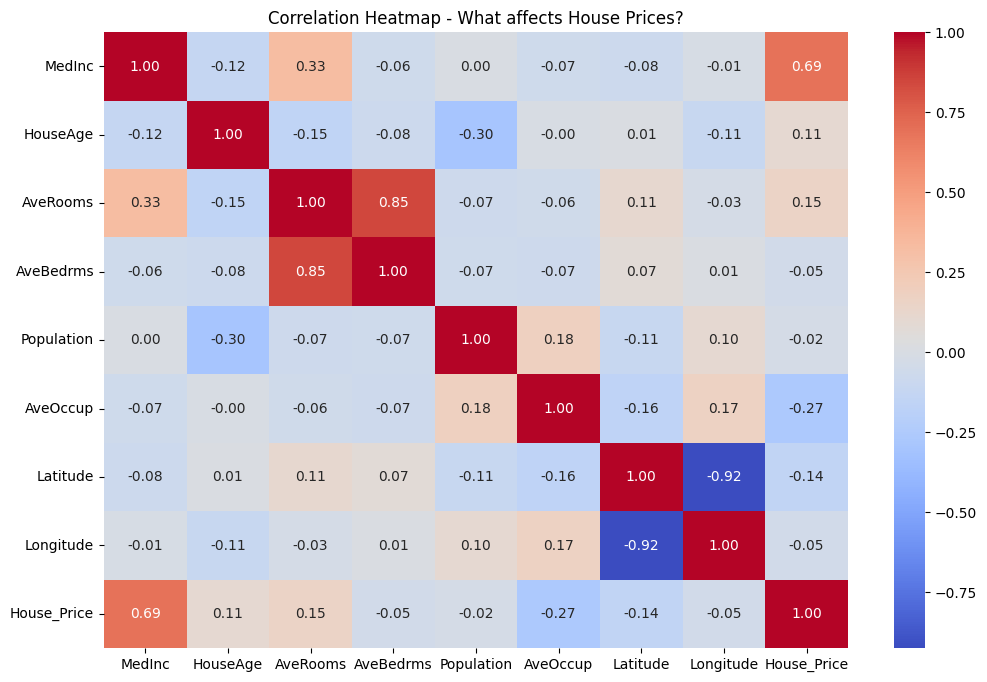

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Calculate the correlation matrix
correlation_matrix = df_cleaned.corr()

# Step 2: Visualizing the correlation using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - What affects House Prices?')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Step 1: Define your Features (X) and Target (y)
# We use MedInc because it has the strongest correlation
X = df_cleaned[['MedInc']]
y = df_cleaned['House_Price']

# Step 2: Split data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Initialize and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 4: Make Predictions
predictions = model.predict(X_test)

# Step 5: Check how accurate the model is
mse = mean_squared_error(y_test, predictions)
print(f"Model Mean Squared Error: {mse:.4f}")

Model Mean Squared Error: 0.6992


In [ ]:
# Step 1: Select multiple features this time
features = ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'Latitude', 'Longitude']
X_multi = df_cleaned[features]
y = df_cleaned['House_Price']

# Step 2: Split the new data
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# Step 3: Train the improved model
multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)

# Step 4: Predict and Evaluate
multi_predictions = multi_model.predict(X_test_m)
multi_mse = mean_squared_error(y_test_m, multi_predictions)

print(f"Old MSE (One Feature): 0.6992")
print(f"New MSE (Multiple Features): {multi_mse:.4f}")

Old MSE (One Feature): 0.6992
New MSE (Multiple Features): 0.4674


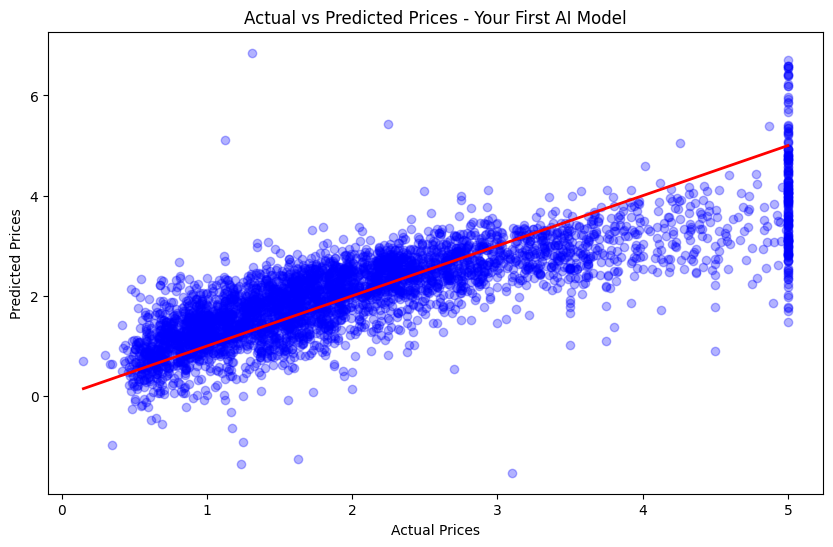

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_m, multi_predictions, alpha=0.3, color='blue')
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], color='red', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices - House Price Predictor ')
plt.show()